# Aeon with `movement`

In [35]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from movement.io.load_poses import from_numpy
from movement.plots import plot_centroid_trajectory
from swc.aeon.io import api as io_api
from swc.aeon.io import reader as io_reader
from scipy.signal import welch

from movement.filtering import (
    interpolate_over_time,
    rolling_filter,
    savgol_filter,
)

## Load Aeon data into `xarray.Dataset`

In [2]:
root = "Z:/aeon/data/ingest"
pose_reader = io_reader.Pose("CameraTop_222*", root)
pose = io_api.load(
    root=root,
    reader=pose_reader,
    start=pd.Timestamp("2024-07-02 14:00"),
    end=pd.Timestamp("2024-07-02 14:10"),
    include_model=False,
)
pose = pose[pose.identity.isin(["BAA-1104569", "BAA-1104568"])]
pose = pose[~pose["part"].str.startswith("anchor_")]
# Out-of-order timestamps so full chunk returned
pose.sort_index(inplace=True)
pose = pose.loc["2024-07-02 14:00:00":"2024-07-02 14:10:00"]
# Convert index to seconds
pose.index = (pose.index - pose.index[0]).total_seconds()
# Infer FPS
frames = pose.index.drop_duplicates().to_numpy()
mean_time_diff = np.diff(frames).mean()
fps = float(np.ceil(1 / mean_time_diff)) if mean_time_diff > 0 else None

keypoints = pose["part"].unique()
individuals = pose["identity"].unique()

# Create position array
multi_idx = pd.MultiIndex.from_product(
    [frames, keypoints, individuals], names=["frame", "part", "identity"]
)
pose_reset = pose.reset_index().set_index(["time", "part", "identity"])
pose_full = pose_reset.reindex(multi_idx)
x_arr = pose_full["x"].values.reshape(len(frames), len(keypoints), len(individuals))
y_arr = pose_full["y"].values.reshape(len(frames), len(keypoints), len(individuals))
pose_arr = np.stack([x_arr, y_arr], axis=1).astype(float)
# Create confidence array
conf_arr = pose_full["part_likelihood"].values.reshape(
    len(frames), len(keypoints), len(individuals)
)
ds = from_numpy(
    position_array=pose_arr,
    confidence_array=conf_arr,
    individual_names=individuals,
    keypoint_names=keypoints,
    fps=fps,
)

2025-05-23 16:55:38.089 | WARNING  | swc.aeon.io.api:load:177 - C:\Users\locha\AppData\Local\Temp\ipykernel_58460\3222142844.py:3: UserWarning: data index for CameraTop_222* contains out-of-order timestamps!
  pose = io_api.load(



In [29]:
ds

<xarray.Dataset> Size: 12MB
Dimensions:      (time: 30050, space: 2, keypoints: 8, individuals: 2)
Coordinates:
  * time         (time) float64 240kB 0.0 0.02 0.04 0.06 ... 600.9 601.0 601.0
  * space        (space) <U1 8B 'x' 'y'
  * keypoints    (keypoints) <U9 288B 'spine3' 'spine2' ... 'nose' 'spine4'
  * individuals  (individuals) <U11 88B 'BAA-1104569' 'BAA-1104568'
Data variables:
    position     (time, space, keypoints, individuals) float64 8MB 1.216e+03 ...
    confidence   (time, keypoints, individuals) object 4MB 0.7734432816505432...
Attributes:
    source_software:  None
    ds_type:          poses
    fps:              50.0
    time_unit:        seconds

## Plot centroid trajectory 

By default, centroid is computed as the mean of all keypoints. 
This can be changed by setting `keypoint` either to a single keypoint or a list of keypoints in ``plot_centroid_trajectory``.

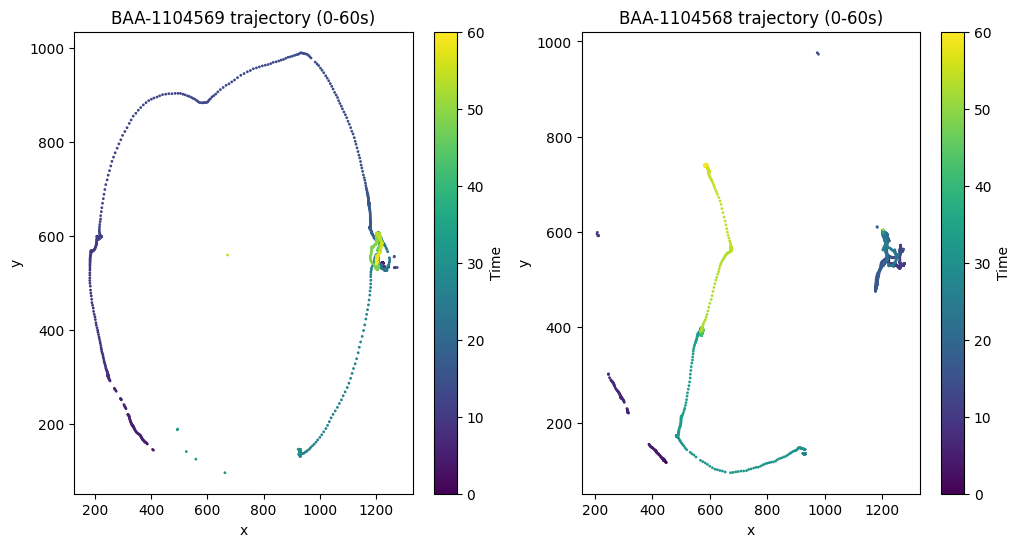

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for i, mouse in enumerate(ds.individuals.values):
    plot_centroid_trajectory(
        ds.position.sel(time=slice(0, 60)), individual=mouse, s=1, ax=ax[i]
    )
    ax[i].set_title(f"{mouse} trajectory (0-60s)")
plt.show()

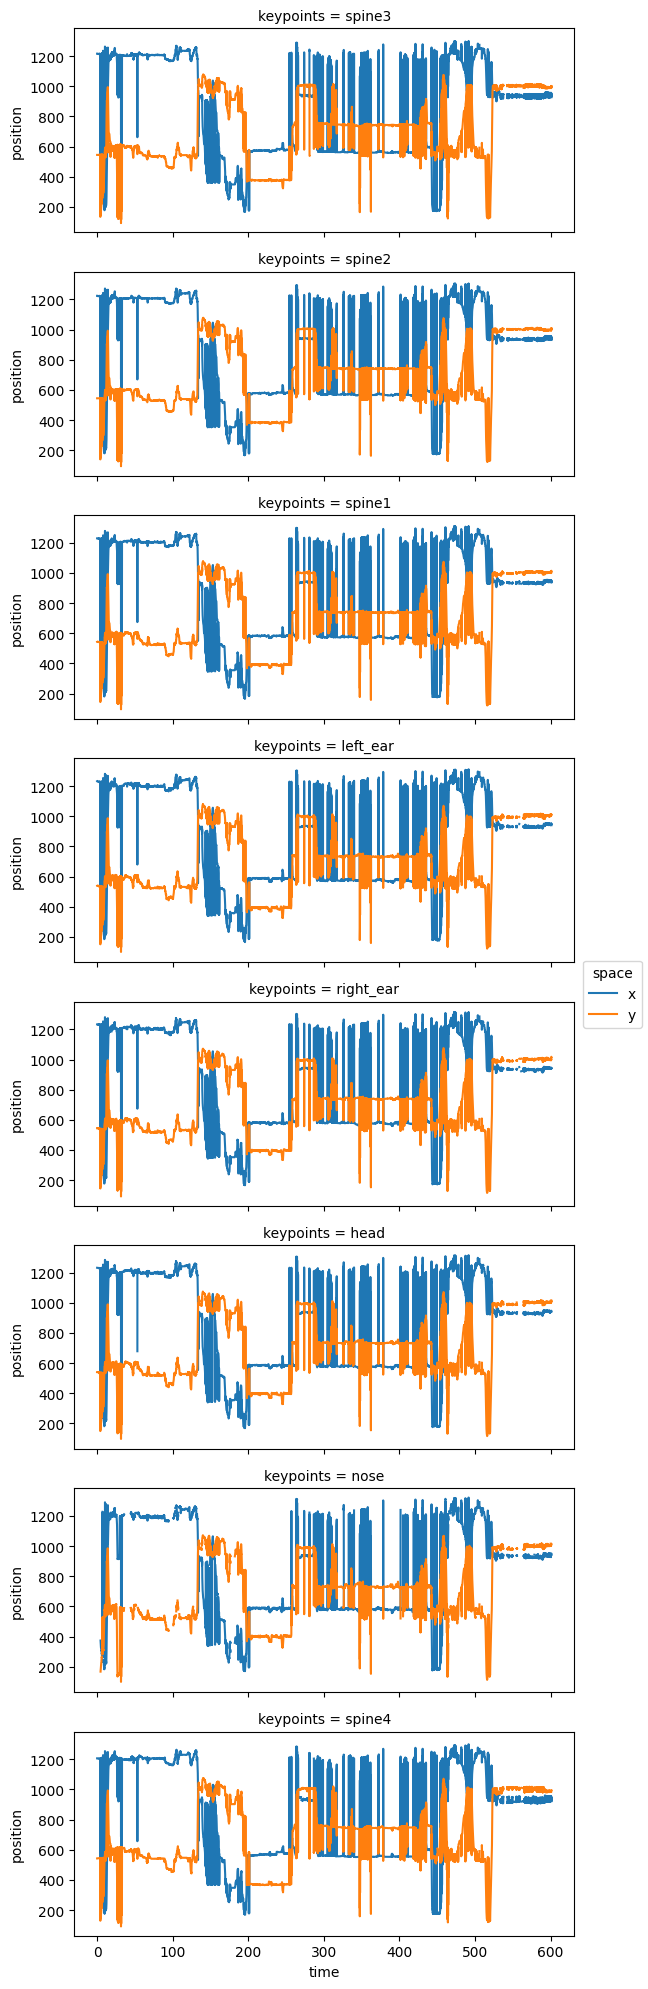

In [ ]:
from movement.filtering import filter_by_confidence, interpolate_over_time

ds.position.isel(individuals=0).plot.line(
    x="time", row="keypoints", hue="space", aspect=2, size=2.5
)

(array([4.34700e+03, 3.42400e+03, 3.17500e+03, 3.90900e+03, 5.09300e+03,
        6.02700e+03, 7.40200e+03, 8.99400e+03, 1.13860e+04, 1.42200e+04,
        2.03720e+04, 3.31790e+04, 5.95600e+04, 1.02353e+05, 1.07291e+05,
        5.21940e+04, 1.68520e+04, 3.44600e+03, 8.24000e+02, 6.40000e+01]),
 array([0.01134047, 0.07756657, 0.14379267, 0.21001876, 0.27624486,
        0.34247095, 0.40869705, 0.47492315, 0.54114924, 0.60737534,
        0.67360144, 0.73982753, 0.80605363, 0.87227972, 0.93850582,
        1.00473192, 1.07095801, 1.13718411, 1.20341021, 1.2696363 ,
        1.3358624 ]),
 <BarContainer object of 20 artists>)

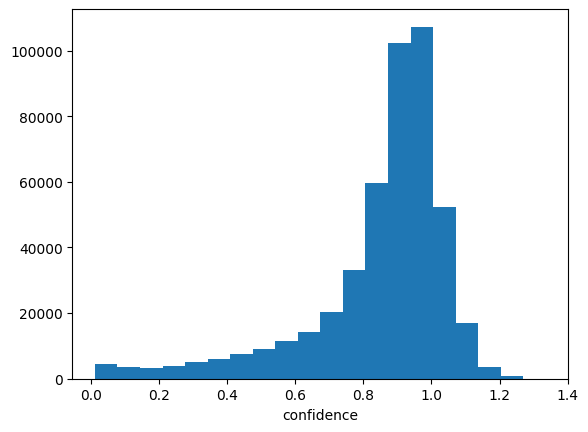

In [57]:
ds.confidence.plot.hist(bins=20)

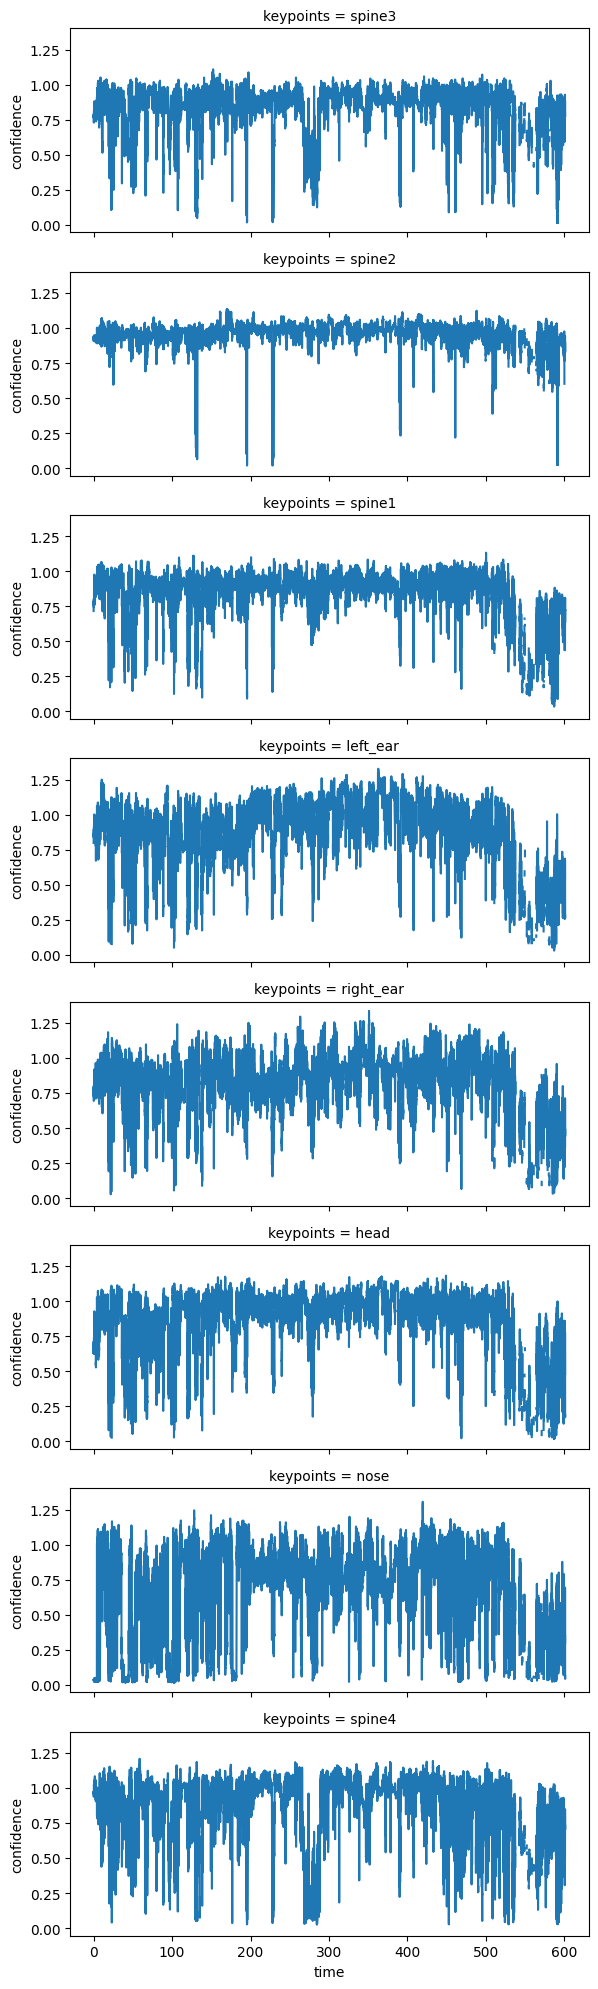

In [61]:
ds.isel(individuals=0).confidence.astype(float).plot.line(
    x="time", row="keypoints", aspect=2, size=2.5
)

In [66]:
ds_conf_gt_06 = ds.copy()
ds_conf_gt_06.update(
    {
        "position": filter_by_confidence(
            ds_conf_gt_06.position,
            ds_conf_gt_06.confidence,
            threshold=0.6,
            print_report=True,
        ),
        "confidence": ds_conf_gt_06.confidence.where(ds_conf_gt_06.confidence >= 0.6),
    }
)


Missing points (marked as NaN) in input
	Individual: BAA-1104569
		spine3: 2009/30050 (6.7%)
		spine2: 1885/30050 (6.3%)
		spine1: 1977/30050 (6.6%)
		left_ear: 1968/30050 (6.5%)
		right_ear: 1965/30050 (6.5%)
		head: 2114/30050 (7.0%)
		nose: 5140/30050 (17.1%)
		spine4: 2535/30050 (8.4%)
	Individual: BAA-1104568
		spine3: 391/30050 (1.3%)
		spine2: 324/30050 (1.1%)
		spine1: 489/30050 (1.6%)
		left_ear: 593/30050 (2.0%)
		right_ear: 622/30050 (2.1%)
		head: 665/30050 (2.2%)
		nose: 3849/30050 (12.8%)
		spine4: 607/30050 (2.0%)

Missing points (marked as NaN) in output
	Individual: BAA-1104569
		spine3: 4007/30050 (13.3%)
		spine2: 2123/30050 (7.1%)
		spine1: 3517/30050 (11.7%)
		left_ear: 4905/30050 (16.3%)
		right_ear: 5154/30050 (17.2%)
		head: 4906/30050 (16.3%)
		nose: 10291/30050 (34.2%)
		spine4: 5679/30050 (18.9%)
	Individual: BAA-1104568
		spine3: 1315/30050 (4.4%)
		spine2: 386/30050 (1.3%)
		spine1: 2470/30050 (8.2%)
		left_ear: 3934/30050 (13.1%)
		right_ear: 3847/30050 (

<xarray.Dataset> Size: 12MB
Dimensions:      (time: 30050, space: 2, keypoints: 8, individuals: 2)
Coordinates:
  * time         (time) float64 240kB 0.0 0.02 0.04 0.06 ... 600.9 601.0 601.0
  * space        (space) <U1 8B 'x' 'y'
  * keypoints    (keypoints) <U9 288B 'spine3' 'spine2' ... 'nose' 'spine4'
  * individuals  (individuals) <U11 88B 'BAA-1104569' 'BAA-1104568'
Data variables:
    position     (time, space, keypoints, individuals) float64 8MB 1.216e+03 ...
    confidence   (time, keypoints, individuals) object 4MB 0.7734432816505432...
Attributes:
    source_software:  None
    ds_type:          poses
    fps:              50.0
    time_unit:        seconds

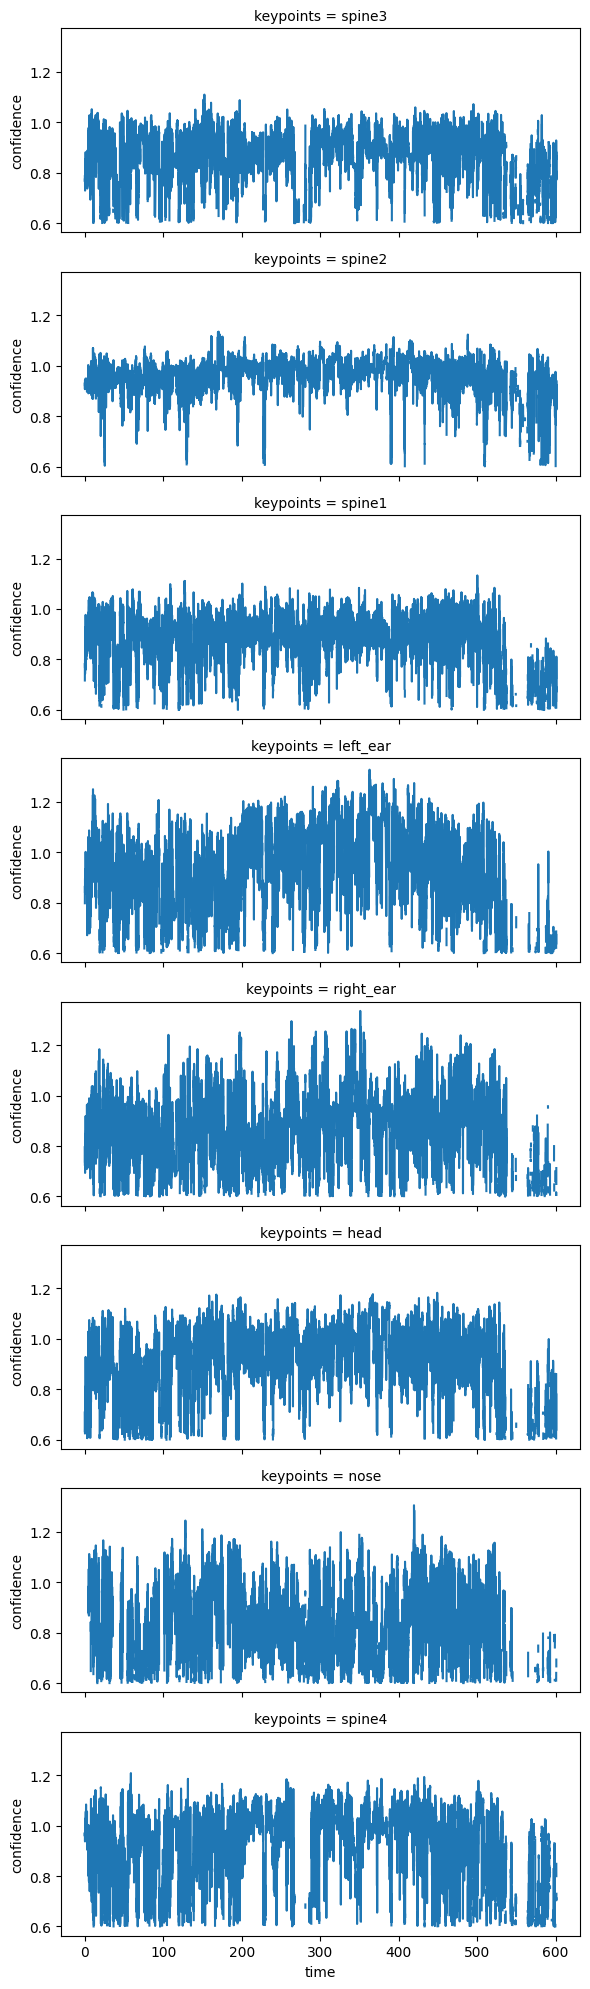

In [67]:
ds_conf_gt_06.isel(individuals=0).confidence.astype(float).plot.line(
    x="time", row="keypoints", aspect=2, size=2.5
)

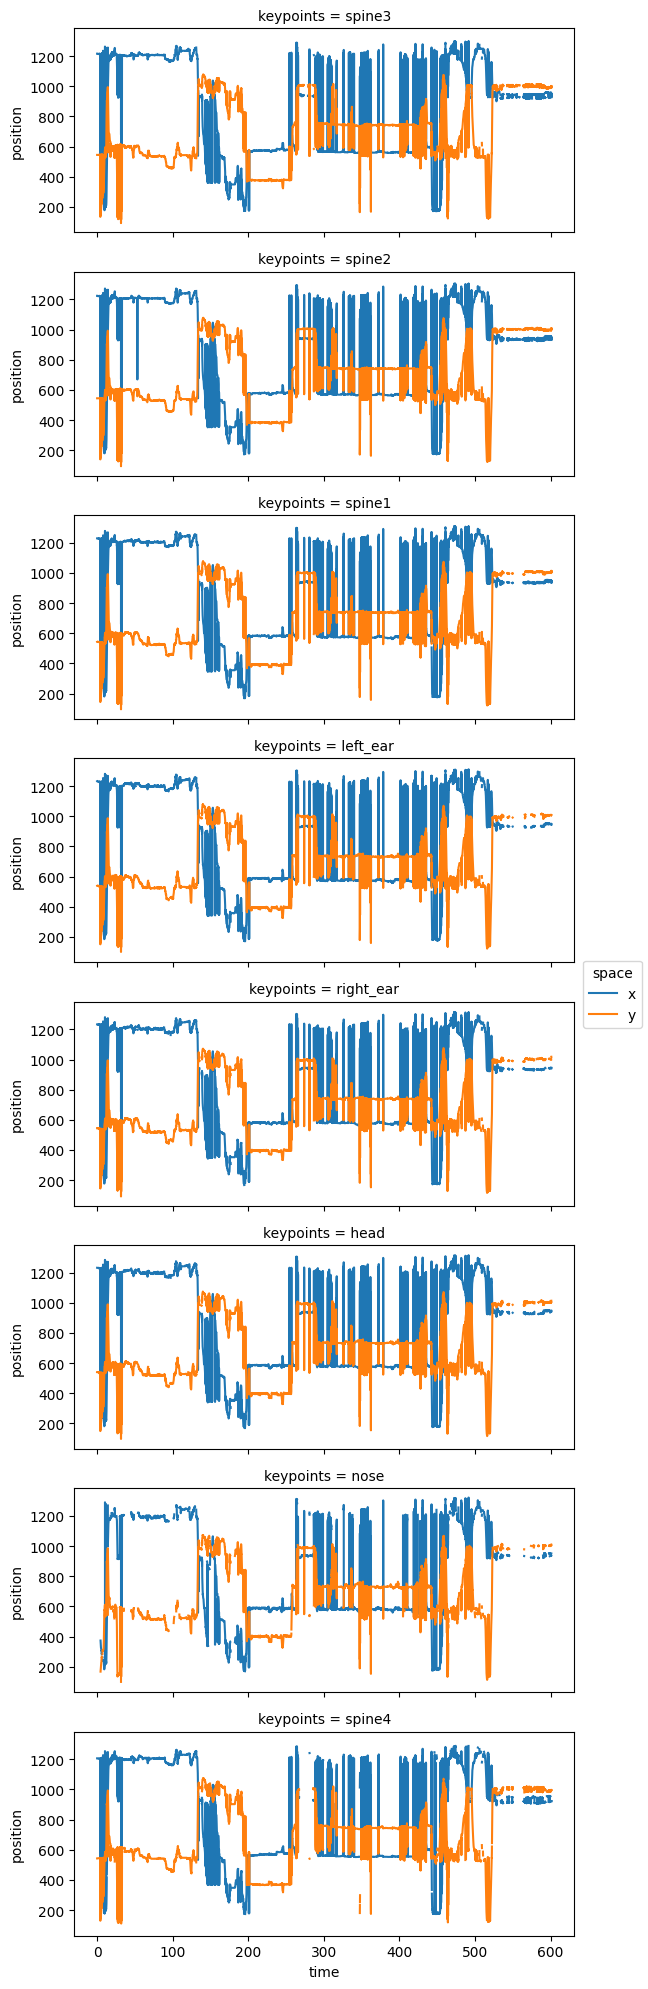

In [68]:
ds_conf_gt_06.position.isel(individuals=0).plot.line(
    x="time", row="keypoints", hue="space", aspect=2, size=2.5
)

## Filtering and smoothing
### Median filter

In [ ]:
window = int(1 * ds.fps)  # 1s window, 50 frames
ds_smooth = ds.copy()
ds_smooth.update(
    {
        "position": rolling_filter(
            ds.position,
            window,
            min_periods=5,  # Require at least 5 consecutive frames without NaN
            statistic="median",
            print_report=True,
        )
    }
)


Missing points (marked as NaN) in input
	Individual: BAA-1104569
		spine3: 2009/30050 (6.7%)
		spine2: 1885/30050 (6.3%)
		spine1: 1977/30050 (6.6%)
		left_ear: 1968/30050 (6.5%)
		right_ear: 1965/30050 (6.5%)
		head: 2114/30050 (7.0%)
		nose: 5140/30050 (17.1%)
		spine4: 2535/30050 (8.4%)
	Individual: BAA-1104568
		spine3: 391/30050 (1.3%)
		spine2: 324/30050 (1.1%)
		spine1: 489/30050 (1.6%)
		left_ear: 593/30050 (2.0%)
		right_ear: 622/30050 (2.1%)
		head: 665/30050 (2.2%)
		nose: 3849/30050 (12.8%)
		spine4: 607/30050 (2.0%)

Missing points (marked as NaN) in output
	Individual: BAA-1104569
		spine3: 837/30050 (2.8%)
		spine2: 837/30050 (2.8%)
		spine1: 910/30050 (3.0%)
		left_ear: 1026/30050 (3.4%)
		right_ear: 1032/30050 (3.4%)
		head: 1047/30050 (3.5%)
		nose: 2464/30050 (8.2%)
		spine4: 919/30050 (3.1%)
	Individual: BAA-1104568
		spine3: 0/30050 (0.0%)
		spine2: 0/30050 (0.0%)
		spine1: 0/30050 (0.0%)
		left_ear: 0/30050 (0.0%)
		right_ear: 7/30050 (0.0%)
		head: 51/30050 (0.2

<xarray.Dataset> Size: 12MB
Dimensions:      (time: 30050, space: 2, keypoints: 8, individuals: 2)
Coordinates:
  * time         (time) float64 240kB 0.0 0.02 0.04 0.06 ... 600.9 601.0 601.0
  * space        (space) <U1 8B 'x' 'y'
  * keypoints    (keypoints) <U9 288B 'spine3' 'spine2' ... 'nose' 'spine4'
  * individuals  (individuals) <U11 88B 'BAA-1104569' 'BAA-1104568'
Data variables:
    position     (time, space, keypoints, individuals) float64 8MB 1.216e+03 ...
    confidence   (time, keypoints, individuals) object 4MB 0.7734432816505432...
Attributes:
    source_software:  None
    ds_type:          poses
    fps:              50.0
    time_unit:        seconds

In [34]:
def plot_raw_and_smooth_timeseries_and_psd(
    ds_raw,
    ds_smooth,
    individual="individual_0",
    keypoint="stinger",
    space="x",
    time_range=None,
):
    # If no time range is specified, plot the entire time series
    if time_range is None:
        time_range = slice(0, ds_raw.time[-1])

    selection = {
        "time": time_range,
        "individuals": individual,
        "keypoints": keypoint,
        "space": space,
    }

    fig, ax = plt.subplots(2, 1, figsize=(10, 6))

    for ds, color, label in zip(
        [ds_raw, ds_smooth], ["k", "r"], ["raw", "smooth"], strict=False
    ):
        # plot position time series
        pos = ds.position.sel(**selection)
        ax[0].plot(
            pos.time,
            pos,
            color=color,
            lw=2,
            alpha=0.7,
            label=f"{label} {space}",
        )

        # interpolate data to remove NaNs in the PSD calculation
        pos_interp = interpolate_over_time(pos, fill_value="extrapolate")

        # compute and plot the PSD
        freq, psd = welch(pos_interp, fs=ds.fps, nperseg=256)
        ax[1].semilogy(
            freq,
            psd,
            color=color,
            lw=2,
            alpha=0.7,
            label=f"{label} {space}",
        )

    ax[0].set_ylabel(f"{space} position (px)")
    ax[0].set_xlabel("Time (s)")
    ax[0].set_title("Time Domain")
    ax[0].legend()

    ax[1].set_ylabel("PSD (px$^2$/Hz)")
    ax[1].set_xlabel("Frequency (Hz)")
    ax[1].set_title("Frequency Domain")
    ax[1].legend()

    plt.tight_layout()
    fig.show()

2025-05-23 17:36:32.940 | WARNING  | matplotlib._api:warn_external:391 - C:\Users\locha\AppData\Local\Temp\ipykernel_58460\2807595218.py:61: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



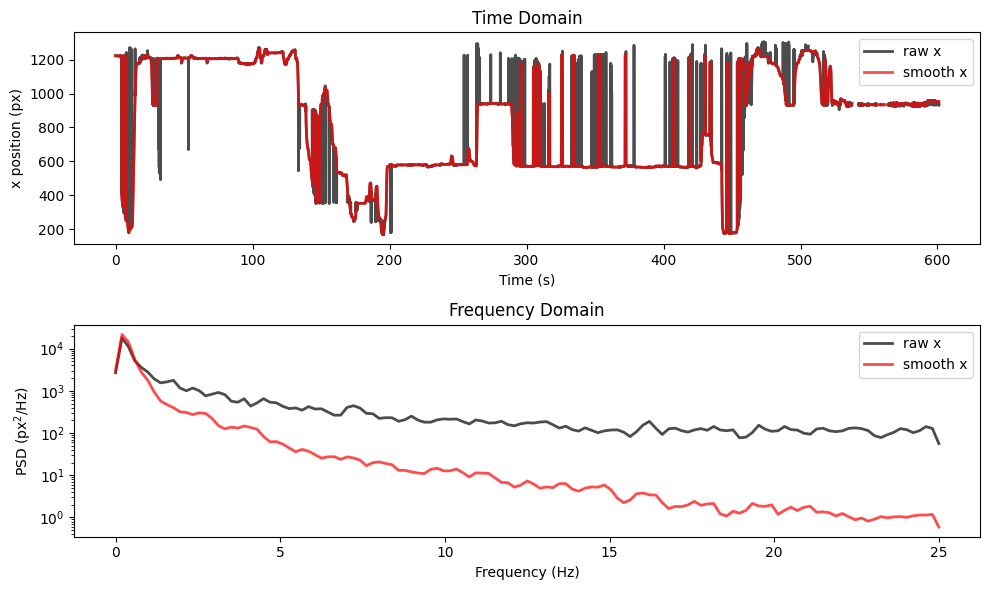

In [ ]:
plot_raw_and_smooth_timeseries_and_psd(
    ds,
    ds_smooth,
    individual=ds.individuals.values[0],
    keypoint="spine2",
)